In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#用 Pandas 讀取 CSV 檔案，存進變數 df（dataframe 的縮寫）
df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv') #匯入CSV格式的檔案
df.head()  # 顯示前 5 筆資料，快速確認資料載入是否正確

,customer_id,as_of_date,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,...,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_type,churn_probability_true
0,1,2025-12-31,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,...,7,1616,0,0,0,0,0,0,No churn,0.048626
1,2,2025-12-31,Auckland,70,65-74,Married,76,1,3,Auto,...,15,1760,1,0,0,0,0,0,No churn,0.067888
2,3,2025-12-31,Bay of Plenty,62,55-64,Married,129,0,1,Auto,...,24,1581,1,0,0,0,0,0,No churn,0.223765
3,4,2025-12-31,Bay of Plenty,47,45-54,Single,104,0,1,Auto,...,17,1688,1,0,0,0,0,0,No churn,0.602455
4,5,2025-12-31,Bay of Plenty,47,45-54,Married,22,1,3,Life,...,24,1592,1,0,0,0,0,0,No churn,0.050723


In [74]:
print(df.shape)    # 回傳資料的維度：(列數(筆數),欄數):(50000, 40)
df.info()    #欄位名稱+資料型態+非空值數量

(50000, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  prem

In [52]:
print(df['churn_flag'].value_counts())                  #流失筆數
print(df['churn_flag'].value_counts(normalize = True))  #流失比率

churn_flag
0    34917
1    15083
Name: count, dtype: int64
churn_flag
0    0.69834
1    0.30166
Name: proportion, dtype: float64


In [53]:
df.describe()    #Pandas 內建的統計摘要函數

,customer_id,age,customer_tenure_months,multi_policy_flag,num_policies,renewal_month,current_premium,premium_last_year,premium_change_pct,num_price_increases_last_3y,...,payout_ratio_12m,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_probability_true
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,51.461700,90.36882,0.318640,1.638760,6.49762,1047.882399,994.319903,0.060795,1.669360,...,0.774165,18.17572,971.374400,1.285900,0.040440,0.493060,0.108480,0.098520,0.301660,0.303564
std,14433.901067,19.644405,51.83518,0.465954,1.041848,3.43503,455.932852,440.611049,0.080826,0.818957,...,0.039917,7.94916,501.320714,1.156213,0.196991,2.673779,0.310989,0.298019,0.458983,0.232942
min,1.000000,18.000000,1.00000,0.000000,1.000000,1.00000,120.000000,92.740000,-0.160200,0.000000,...,0.550000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018915
25%,12500.750000,34.000000,45.00000,0.000000,1.000000,4.00000,745.707500,701.577500,0.004600,1.000000,...,0.750000,13.00000,560.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.130210
50%,25000.500000,52.000000,90.00000,0.000000,1.000000,6.00000,1009.755000,954.720000,0.059800,2.000000,...,0.750000,18.00000,981.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.242322
75%,37500.250000,68.000000,135.00000,1.000000,2.000000,9.00000,1324.462500,1259.262500,0.116300,2.000000,...,0.800000,24.00000,1402.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.414728
max,50000.000000,85.000000,180.00000,1.000000,4.000000,12.00000,3348.350000,3374.460000,0.410500,3.000000,...,0.850000,53.00000,1824.000000,10.000000,1.000000,31.000000,1.000000,1.000000,1.000000,1.000000


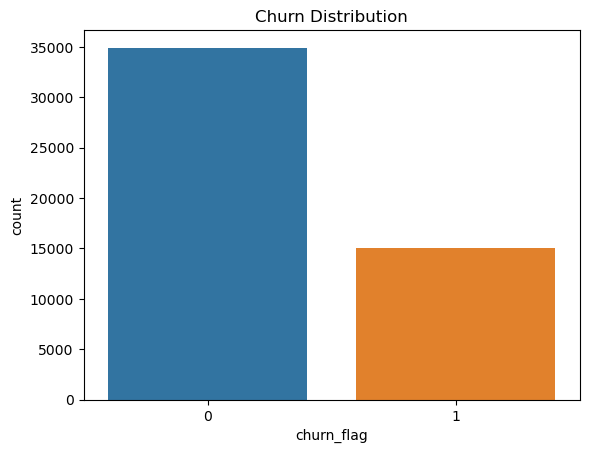

In [54]:
sns.countplot(x='churn_flag', data = df)  #Seaborn 的長條圖函數，用來計算每個類別出現幾次
plt.title('Churn Distribution')
plt.show()

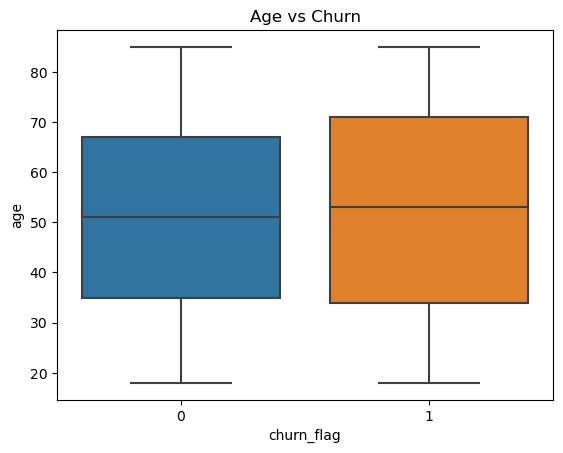

In [55]:
# Seaborn 的箱型圖函數，用來比較兩組的數值分佈
sns.boxplot(x='churn_flag', y='age', data=df)  
plt.title('Age vs Churn')
plt.show()

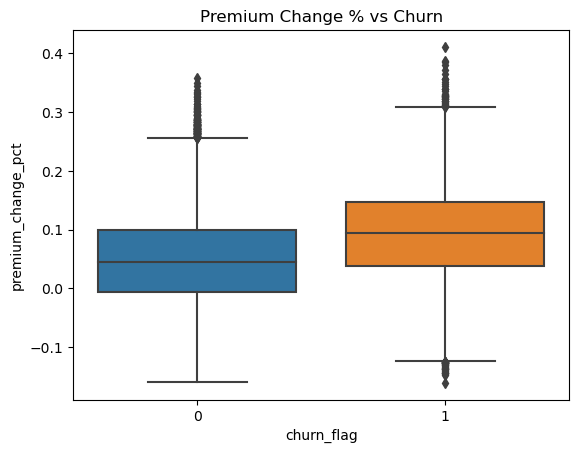

In [56]:
sns.boxplot(x='churn_flag', y='premium_change_pct', data=df)
plt.title('Premium Change % vs Churn')
plt.show()

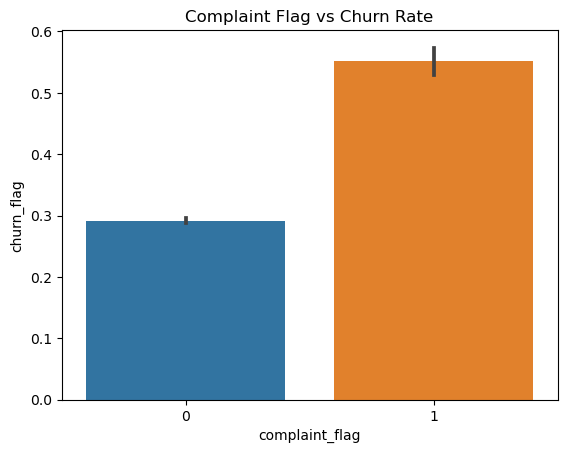

In [57]:
#長條圖，用來顯示某個類別對應的數值平均
sns.barplot(x='complaint_flag', y='churn_flag', data=df)
plt.title('Complaint Flag vs Churn Rate')
plt.show()

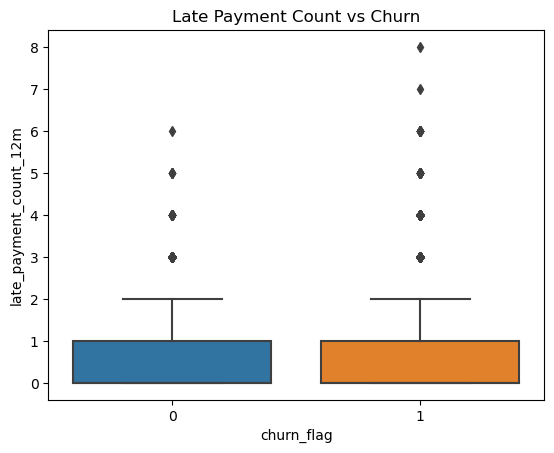

In [58]:
sns.boxplot(x='churn_flag', y='late_payment_count_12m',data=df)  #延遲付款次數
plt.title('Late Payment Count vs Churn')
plt.show()

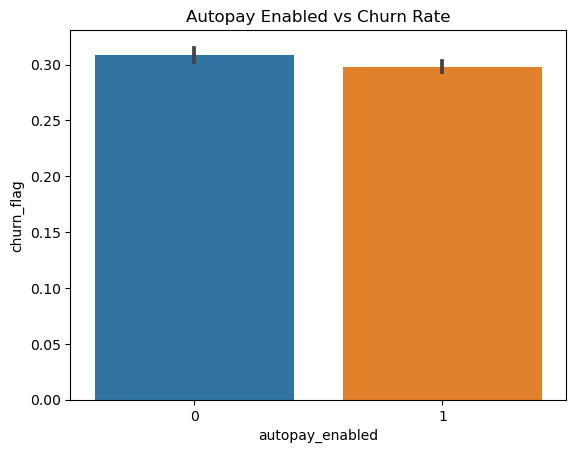

In [59]:
sns.barplot(x='autopay_enabled', y='churn_flag', data=df)
plt.title('Autopay Enabled vs Churn Rate')
plt.show()

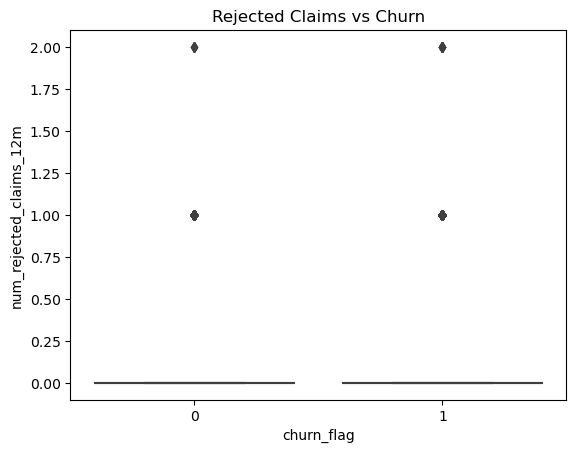

In [60]:
sns.boxplot(x='churn_flag', y='num_rejected_claims_12m', data=df)  #被拒絕理賠
plt.title('Rejected Claims vs Churn')
plt.show()

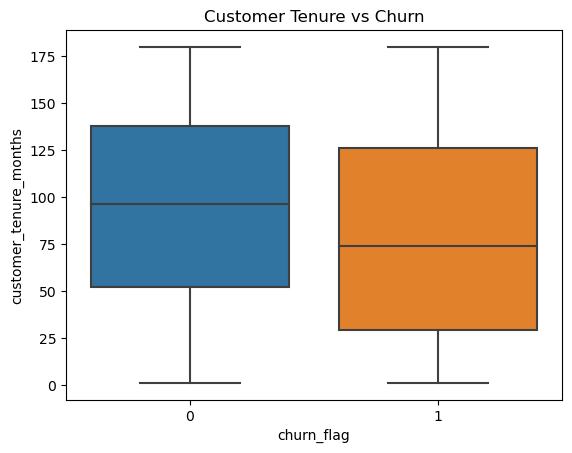

In [61]:
sns.boxplot(x='churn_flag', y='customer_tenure_months', data=df) #客戶投保年資
plt.title('Customer Tenure vs Churn')
plt.show()

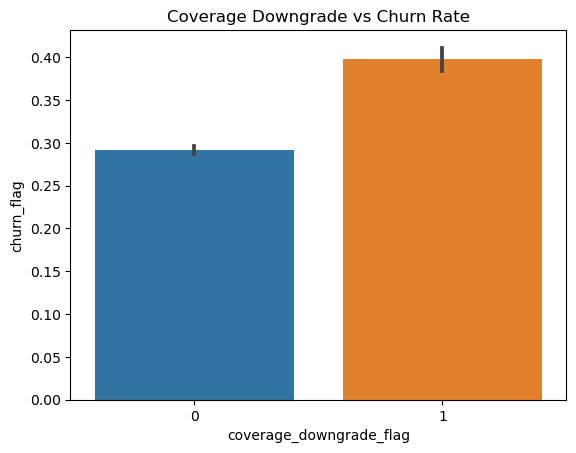

In [62]:
sns.barplot(x='coverage_downgrade_flag', y='churn_flag', data=df)  #主動降低保障的客戶
plt.title('Coverage Downgrade vs Churn Rate')
plt.show()

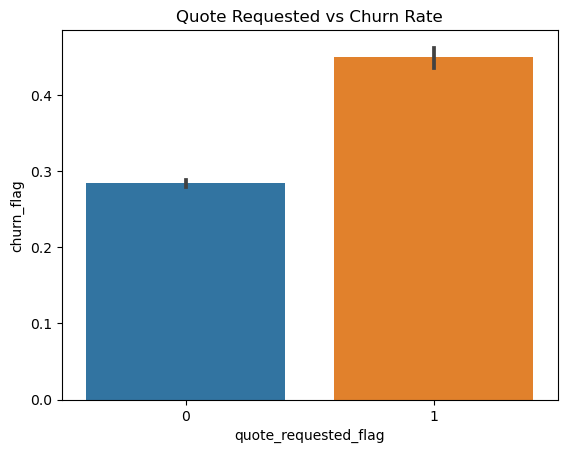

In [63]:
sns.barplot(x='quote_requested_flag', y='churn_flag',data=df)  #客戶主動詢價
plt.title('Quote Requested vs Churn Rate')
plt.show()

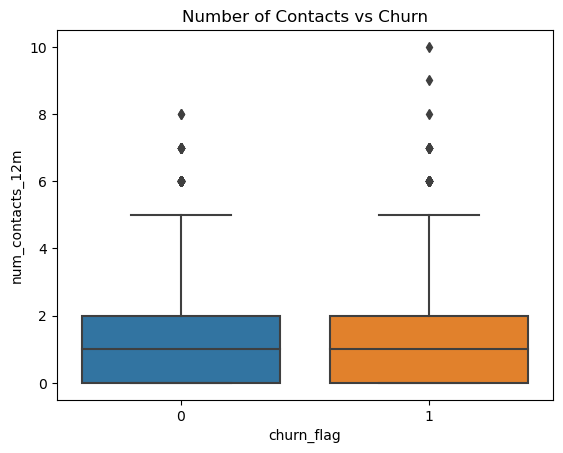

In [64]:
sns.boxplot(x='churn_flag', y='num_contacts_12m', data=df)  #12個月內聯絡次數
plt.title('Number of Contacts vs Churn')
plt.show()

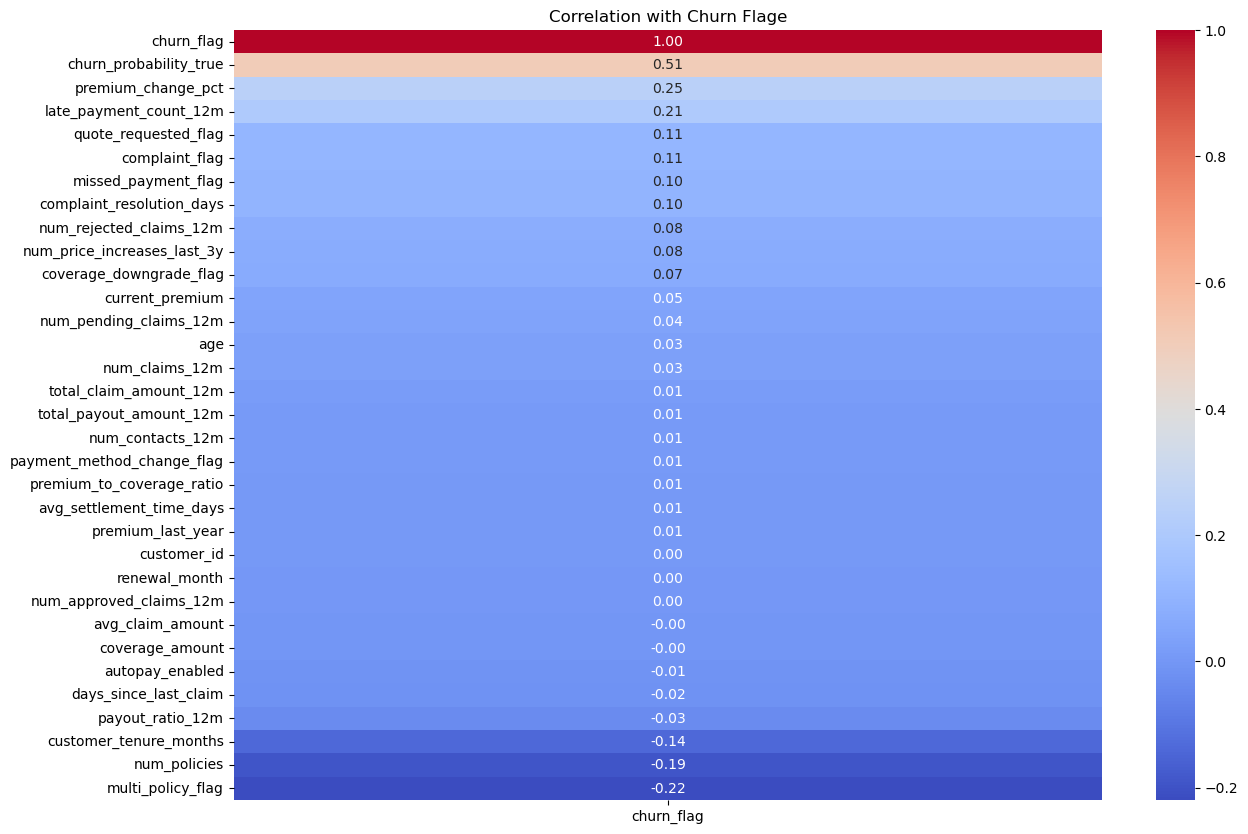

In [65]:
#correlation heatmap
plt.figure(figsize=(14,10))  #圖表尺寸:寬14、高10英吋
corr = df.corr(numeric_only=True) #計算所有數值欄位之間的相關係數
sns.heatmap(corr[['churn_flag']].sort_values('churn_flag',ascending=False),
                 annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation with Churn Flage')
plt.show()


In [66]:
from sklearn.linear_model import LogisticRegression  #sklearn是 Python 最主流的機器學習套件
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [67]:
features = [
    'age', 'customer_tenure_months', 'premium_change_pct',
    'num_policies', 'multi_policy_flag', 'complaint_flag',
    'quote_requested_flag', 'coverage_downgrade_flag',
    'late_payment_count_12m', 'num_contacts_12m'
]

X = df[features]
y = df['churn_flag']
# 切分訓練集和測試集(80% 訓練，20% 測試)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"訓練集：{x_train.shape[0]} 筆")
print(f"測試集：{x_test.shape[0]}筆")

訓練集：40000 筆
測試集：10000筆


In [68]:
# 標準化數值欄位
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 訓練模型
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train_scaled, y_train)

print("模型訓練完成")

模型訓練完成


In [69]:
#預測測試集
y_pred = model.predict(x_test_scaled)
#評估報告
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.91      0.84      7012
           1       0.65      0.38      0.48      2988

    accuracy                           0.75     10000
   macro avg       0.71      0.65      0.66     10000
weighted avg       0.74      0.75      0.73     10000



做流失預測，優先順序：
recall(1) > f1-score(1) > precision(1) > accuracy
precision(1): 0.65 預測流失的客戶中，65% 真的流失
recall(1): 0.38 真正流失的客戶中，只抓到 38%
f1-score(1): 0.48 綜合表現偏低
accuracy: 0.75 整體預測對的比例

c:\Users\user\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36074 (\N{CJK UNIFIED IDEOGRAPH-8CEA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from current font.
  fig.canvas.print_figure(bytes_io, *

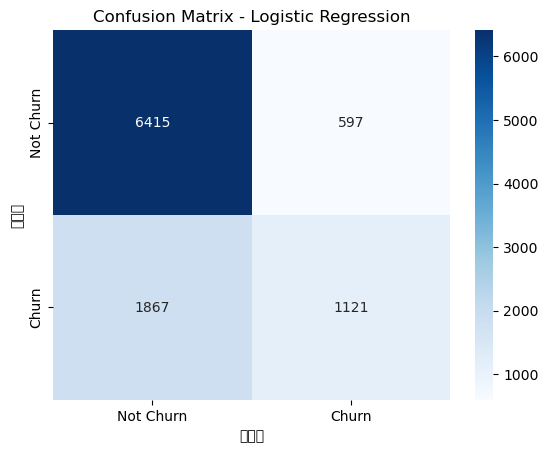

In [70]:
#confusion matrix 視覺化
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Not Churn', 'Churn'],
            yticklabels = ['Not Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')

plt.ylabel('真實質')
plt.xlabel('預測值')
plt.show()

關鍵問題：FN = 1867
真正流失的客戶有 2988 筆，模型漏掉了 1867 筆，只抓到 1121 筆。
這就是為什麼 recall 只有 0.38——超過一半的流失客戶被漏掉了。

In [75]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
#建立 100 棵決策樹，最後投票決定結果,100 是常用的起點
rf_model.fit(x_train_scaled, y_train)
print("Random Forest 訓練完成")

Random Forest 訓練完成


In [76]:
y_pred_rf = rf_model.predict(x_test_scaled)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.89      0.83      7012
           1       0.62      0.41      0.50      2988

    accuracy                           0.75     10000
   macro avg       0.70      0.65      0.66     10000
weighted avg       0.73      0.75      0.73     10000



Random Forest recall 從 0.38 提升到 0.41，進步有限。
兩個模型表現接近，這代表問題不在模型選擇，而是特徵本身的預測力有限。